Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import pickle

**Data Collection and Processing**

In [2]:
# load the dataset to a pandas dataframe
data = pd.read_csv("/content/placementdata.csv")

In [3]:
print (type(data))

<class 'pandas.core.frame.DataFrame'>


In [4]:
data.shape

(1000, 11)

In [5]:
data.head()

,StudentID,CGPA,Internships,Projects,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,6438,7.2,2,2,88,4.8,No,Yes,55,65,NotPlaced
1,1889,7.3,1,2,81,4.5,Yes,Yes,56,71,Placed
2,1385,8.3,1,2,73,3.6,No,Yes,57,71,Placed
3,2814,7.2,1,1,67,4.3,No,No,74,72,NotPlaced
4,1939,7.6,0,1,67,4.3,Yes,Yes,59,69,NotPlaced


In [6]:
data.tail()

,StudentID,CGPA,Internships,Projects,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
995,5552,8.0,2,2,89,4.2,Yes,Yes,82,84,Placed
996,126,7.7,1,2,73,4.0,No,Yes,65,75,Not Placed
997,6043,8.4,2,3,89,4.8,Yes,Yes,76,85,Placed
998,2018,8.9,2,3,90,4.8,Yes,Yes,82,88,Placed
999,6863,6.6,2,3,85,4.8,Yes,Yes,79,85,Not Placed


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  1000 non-null   int64  
 1   CGPA                       1000 non-null   float64
 2   Internships                1000 non-null   int64  
 3   Projects                   1000 non-null   int64  
 4   AptitudeTestScore          1000 non-null   int64  
 5   SoftSkillsRating           1000 non-null   float64
 6   ExtracurricularActivities  1000 non-null   object 
 7   PlacementTraining          1000 non-null   object 
 8   SSC_Marks                  1000 non-null   int64  
 9   HSC_Marks                  1000 non-null   int64  
 10  PlacementStatus            1000 non-null   object 
dtypes: float64(2), int64(6), object(3)
memory usage: 86.1+ KB


In [8]:
data.columns = data.columns.str.strip()

In [9]:
data.columns

Index(['StudentID', 'CGPA', 'Internships', 'Projects', 'AptitudeTestScore',
       'SoftSkillsRating', 'ExtracurricularActivities', 'PlacementTraining',
       'SSC_Marks', 'HSC_Marks', 'PlacementStatus'],
      dtype='object')

In [10]:
data = data.drop(columns=["StudentID","HSC_Marks"])

In [11]:
data.head()

,CGPA,Internships,Projects,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,PlacementStatus
0,7.2,2,2,88,4.8,No,Yes,55,NotPlaced
1,7.3,1,2,81,4.5,Yes,Yes,56,Placed
2,8.3,1,2,73,3.6,No,Yes,57,Placed
3,7.2,1,1,67,4.3,No,No,74,NotPlaced
4,7.6,0,1,67,4.3,Yes,Yes,59,NotPlaced


In [12]:
# checking the number of the missing values
print (data.isnull().sum())

CGPA                         0
Internships                  0
Projects                     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
PlacementStatus              0
dtype: int64


In [13]:
# Check duplicate values
print(data.duplicated().sum())

13


In [14]:
data = data.drop_duplicates()

In [15]:
print(data.duplicated().sum())

0


In [16]:
print(data.shape)

(987, 9)


In [17]:
print(data.describe())

             CGPA  Internships    Projects  AptitudeTestScore  \
count  987.000000   987.000000  987.000000         987.000000   
mean     7.770213     1.098278    2.073961          80.378926   
std      0.634268     0.663040    0.857848           7.704105   
min      6.500000     0.000000    0.000000          60.000000   
25%      7.400000     1.000000    1.000000          74.000000   
50%      7.800000     1.000000    2.000000          81.000000   
75%      8.300000     2.000000    3.000000          87.000000   
max      9.100000     2.000000    3.000000          90.000000   

       SoftSkillsRating   SSC_Marks  
count        987.000000  987.000000  
mean           4.371834   70.221884  
std            0.380425   10.433913  
min            3.000000   55.000000  
25%            4.100000   60.000000  
50%            4.400000   72.000000  
75%            4.700000   79.000000  
max            4.800000   90.000000  


In [18]:
data['PlacementStatus'] = data['PlacementStatus']. replace('Not Placed', 'NotPlaced')

print(data['PlacementStatus'].value_counts())

PlacementStatus
NotPlaced    500
Placed       487
Name: count, dtype: int64


In [19]:
print(data.dtypes)

CGPA                         float64
Internships                    int64
Projects                       int64
AptitudeTestScore              int64
SoftSkillsRating             float64
ExtracurricularActivities     object
PlacementTraining             object
SSC_Marks                      int64
PlacementStatus               object
dtype: object


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['PlacementStatus'] = le.fit_transform(data['PlacementStatus'])
data['PlacementTraining'] = le.fit_transform(data['PlacementTraining'])
data['ExtracurricularActivities'] = le.fit_transform(data['ExtracurricularActivities'])

In [21]:
print(data.head())

   CGPA  Internships  Projects  AptitudeTestScore  SoftSkillsRating  \
0   7.2            2         2                 88               4.8   
1   7.3            1         2                 81               4.5   
2   8.3            1         2                 73               3.6   
3   7.2            1         1                 67               4.3   
4   7.6            0         1                 67               4.3   

   ExtracurricularActivities  PlacementTraining  SSC_Marks  PlacementStatus  
0                          0                  1         55                0  
1                          1                  1         56                1  
2                          0                  1         57                1  
3                          0                  0         74                0  
4                          1                  1         59                0  


In [22]:
X = data.drop(columns='PlacementStatus', axis=1)
Y = data['PlacementStatus']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [25]:
Y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(Y_test, Y_pred))

Accuracy: 0.797979797979798


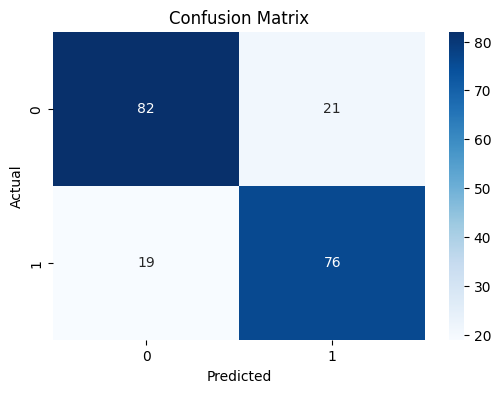

In [27]:
# Confusion matrix
cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [28]:
print(data.dtypes)

CGPA                         float64
Internships                    int64
Projects                       int64
AptitudeTestScore              int64
SoftSkillsRating             float64
ExtracurricularActivities      int64
PlacementTraining              int64
SSC_Marks                      int64
PlacementStatus                int64
dtype: object


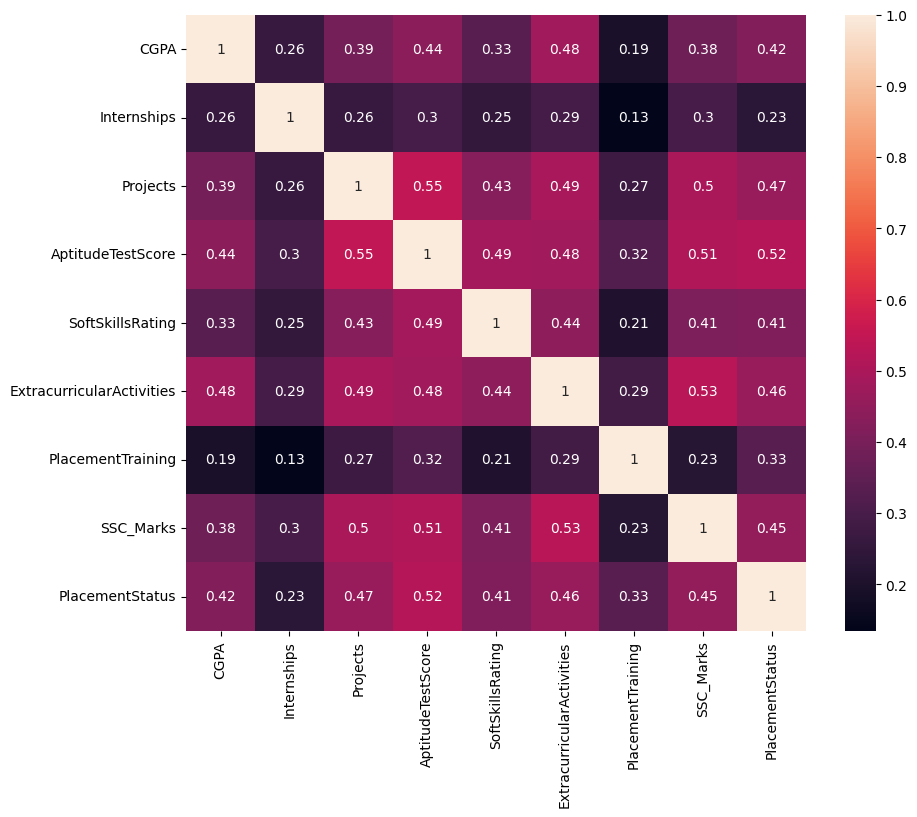

In [29]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True)
plt.show()

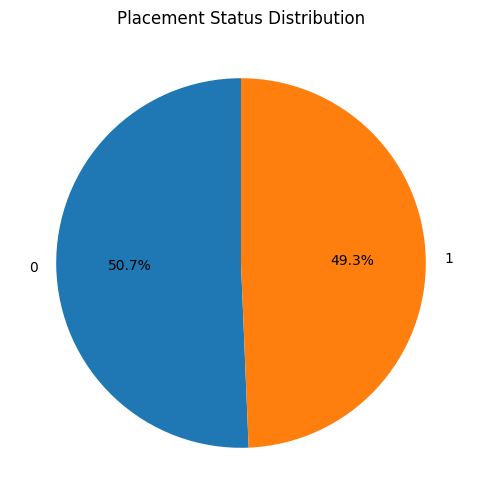

In [30]:
placement_counts = data['PlacementStatus'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(placement_counts, labels=placement_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Placement Status Distribution')
plt.show()

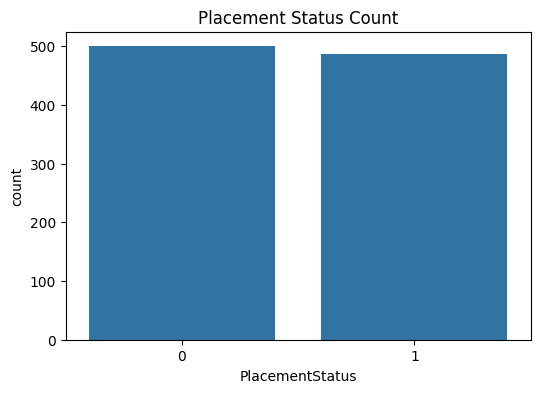

In [31]:
plt. figure(figsize=(6,4))
sns.countplot(x='PlacementStatus', data=data)
plt.title('Placement Status Count')
plt.show()

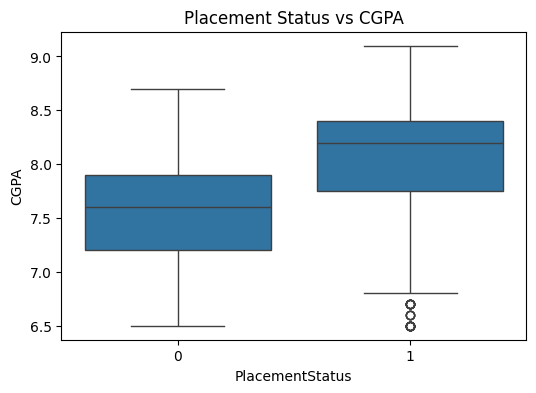

In [32]:
plt.figure(figsize=(6,4))
sns.boxplot(x='PlacementStatus', y='CGPA', data=data)
plt.title('Placement Status vs CGPA')
plt.show()


In [33]:
# Classification Report
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.80       103
           1       0.78      0.80      0.79        95

    accuracy                           0.80       198
   macro avg       0.80      0.80      0.80       198
weighted avg       0.80      0.80      0.80       198



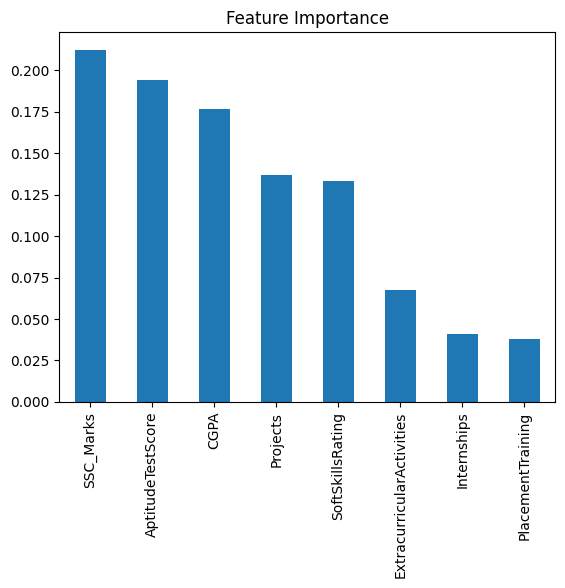

In [34]:
#Feature Importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind= 'bar')
plt.title('Feature Importance')
plt.show()

In [35]:
# Save Model
pickle.dump(model, open('placement_model.pkl', 'wb'))